# Práctica 5 - Análisis Exploratorio de Datos (EDA)

**Sesión 5 - Exploración de datos**    
**Herramientas:** Python, pandas y Matplotlib  
**Dataset:** `clientes_ecommerce.csv`

## Objetivos

En esta práctica aprenderás a:

- realizar un análisis exploratorio de un dataset
- estudiar distribuciones numéricas y categóricas
- interpretar media, mediana, cuartiles y desviación estándar
- utilizar histogramas, gráficos de barras, boxplots y diagramas de dispersión
- detectar posibles valores atípicos mediante el IQR
- estudiar relaciones entre variables
- calcular e interpretar correlaciones
- comparar grupos mediante `groupby()` y `crosstab()`
- diferenciar asociación y causalidad
- comunicar hallazgos respaldados por evidencia

> **Importante:** no basta con generar resultados o gráficos. Cada análisis debe ir acompañado de una **interpretación**

## Preparación

Coloca `clientes_ecommerce.csv` en la misma carpeta que este notebook.

Importa NumPy, pandas y Matplotlib y carga el dataset en un DataFrame llamado `df`

In [33]:
# TODO: importa numpy, pandas y matplotlib.pyplot
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt


# TODO: carga clientes_ecommerce.csv en un DataFrame llamado df
df = pd.read_csv('clientes_ecommerce.csv')

# Parte 1 - Inspección inicial

## Ejercicio 1

Realiza una inspección inicial:

1. Muestra las primeras 10 filas.
2. Consulta las dimensiones.
3. Muestra los nombres de las columnas.
4. Consulta los tipos de datos.
5. Utiliza `info()`.

In [4]:
# TODO: muestra las primeras 10 filas
df.head(10)

,cliente_id,edad,antiguedad_meses,ingresos_anuales,gasto_mensual,num_compras,devoluciones,dispositivo,zona,nivel_fidelidad,satisfaccion,compra_proximo_mes
0,20001,67,102.0,9000.00,60.73,7,3,Móvil,Oeste,Oro,5,No
1,20002,28,93.0,35683.86,131.74,6,1,Móvil,Este,Bronce,2,No
2,20003,19,87.0,37152.19,55.33,8,1,Ordenador,Este,Plata,5,Sí
3,20004,55,79.0,40158.29,24.33,7,0,Ordenador,Norte,Bronce,4,Sí
4,20005,39,3.0,27317.06,88.78,5,0,Móvil,Sur,Bronce,4,No
5,20006,45,25.0,32627.01,59.77,9,2,Móvil,Este,Bronce,5,No
6,20007,22,105.0,44101.68,109.67,8,0,Móvil,Norte,Oro,5,Sí
7,20008,39,90.0,44882.10,57.56,7,2,Ordenador,Norte,Plata,2,Sí
8,20009,55,56.0,55299.19,49.94,6,2,Móvil,Sur,Bronce,5,No
9,20010,38,93.0,9000.00,110.69,10,2,Ordenador,Centro,Oro,4,Sí


In [5]:
# TODO: consulta las dimensiones
df.shape

(400, 12)

In [7]:
# TODO: muestra los nombres de las columnas uno debajo del otro
df.columns
for c in df.columns:
    print(c)

cliente_id
edad
antiguedad_meses
ingresos_anuales
gasto_mensual
num_compras
devoluciones
dispositivo
zona
nivel_fidelidad
satisfaccion
compra_proximo_mes


In [13]:
# TODO: consulta los tipos de datos
#df.dtypes
for columna, tipo in df.dtypes.items():
    print(f"{columna}: {tipo}")

cliente_id: int64
edad: int64
antiguedad_meses: float64
ingresos_anuales: float64
gasto_mensual: float64
num_compras: int64
devoluciones: int64
dispositivo: str
zona: str
nivel_fidelidad: str
satisfaccion: int64
compra_proximo_mes: str


In [10]:
# TODO: utiliza info()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          400 non-null    int64  
 1   edad                400 non-null    int64  
 2   antiguedad_meses    395 non-null    float64
 3   ingresos_anuales    396 non-null    float64
 4   gasto_mensual       397 non-null    float64
 5   num_compras         400 non-null    int64  
 6   devoluciones        400 non-null    int64  
 7   dispositivo         400 non-null    str    
 8   zona                400 non-null    str    
 9   nivel_fidelidad     400 non-null    str    
 10  satisfaccion        400 non-null    int64  
 11  compra_proximo_mes  400 non-null    str    
dtypes: float64(3), int64(5), str(4)
memory usage: 37.6 KB


### Responde

1. ¿Cuántas muestras contiene?
2. ¿Cuántas columnas?
3. ¿Cuál es la unidad de observación?
4. ¿Cuál es el identificador?
5. ¿Cuál es el target?
6. ¿Qué columnas tienen valores ausentes?

**Respuesta:**  
Escribe aquí.

# Parte 2 - Exploración de una variable numérica

Vamos a estudiar `gasto_mensual`.

## Ejercicio 2 - Estadística descriptiva

Obtén el número de valores, media, mediana, desviación estándar, mínimo, \(Q_1\), \(Q_2\), \(Q_3\) y máximo.

In [25]:
# TODO: muestra describe() para gasto_mensual
print (df['gasto_mensual'].describe())#['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']


# TODO: calcula las medidas necesarias
print ("Mediana:", df['gasto_mensual'].median())
print ("Q1:", df['gasto_mensual'].quantile(0.25))
print ("Q2:", df['gasto_mensual'].quantile(0.50))
print ("Q3:" ,df['gasto_mensual'].quantile(0.75))

count    397.000000
mean      69.089320
std       39.023238
min        5.770000
25%       39.720000
50%       61.170000
75%       90.150000
max      260.000000
Name: gasto_mensual, dtype: float64
Mediana: 61.17
Q1: 39.72
Q2: 61.17
Q3: 90.15


### Completa

| Medida | Valor |
|---|---:|
| Número de valores | 397 |
| Media | 69.089320 |
| Mediana | 61.17 |
| Desviación estándar | 39.023238 |
| Mínimo | 5.770000 |
| Q1 | 39.72 |
| Q2 | 61.17 |
| Q3 | 90.15 |
| Máximo | 260.000000 |

### Interpreta

1. ¿Coinciden exactamente media y mediana?
2. ¿Cuál es mayor?
3. ¿Qué puede indicar esta diferencia sobre la distribución?
4. ¿Entre qué valores se encuentra aproximadamente el 50 % central?

**Respuesta:**  
Escribe aquí.

# Parte 3 - Visualizar la distribución

## Ejercicio 3 - Histograma

Crea un histograma de `gasto_mensual` utilizando aproximadamente `bins=15`.

Añade título y etiquetas en ambos ejes.

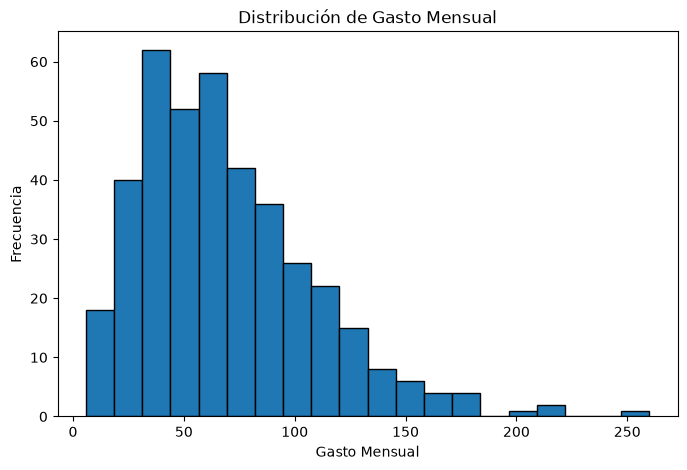

In [38]:
# TODO: crea el histograma de gasto_mensual
plt.figure(figsize=(8,5))
plt.hist(df['gasto_mensual'].dropna(), bins=20, edgecolor='black')
plt.title('Distribución de Gasto Mensual')
plt.xlabel('Gasto Mensual')
plt.ylabel('Frecuencia')
plt.show()

### Interpreta

1. ¿Dónde parece concentrarse la mayoría de los clientes?
2. ¿La distribución parece aproximadamente simétrica?
3. ¿Existe una cola hacia valores altos o bajos?
4. ¿Observas valores alejados del resto?

**Respuesta:**  
Escribe aquí.

# Parte 4 - Boxplot y valores atípicos

## Ejercicio 4

Representa `gasto_mensual` mediante un boxplot. Trata adecuadamente los valores ausentes.

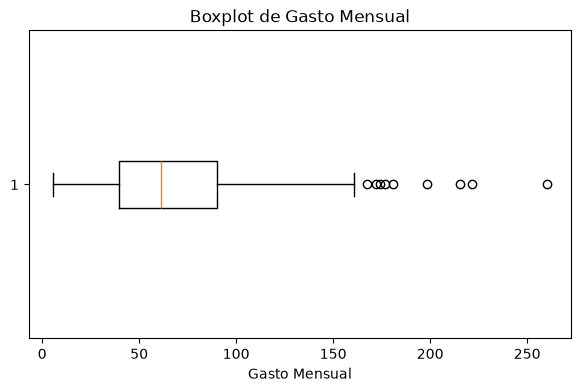

In [39]:
# TODO: crea un boxplot de gasto_mensual
plt.figure(figsize=(7,4))
plt.boxplot(df['gasto_mensual'].dropna(), orientation='horizontal')
plt.xlabel('Gasto Mensual')
plt.title('Boxplot de Gasto Mensual')
plt.show()

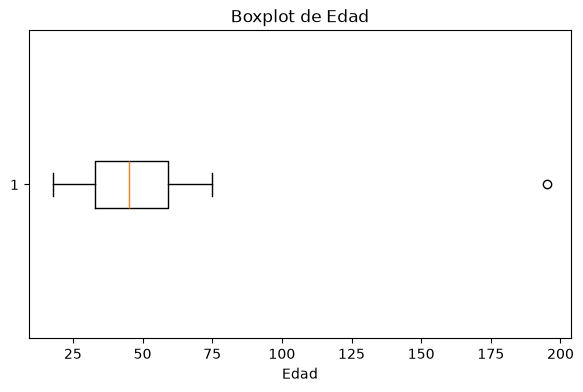

Q1: 33.0
Q2: 45.0
Q3: 59.0
IQR: 26.0
Límite inferior: -6.0
Límite superior: 98.0


In [49]:
#Boxplot de edad
plt.figure(figsize=(7,4))
plt.boxplot(df['edad'].dropna(), orientation='horizontal')
plt.xlabel('Edad')
plt.title('Boxplot de Edad')
plt.show()
Q1 = df['edad'].quantile(0.25)
Q2 = df['edad'].quantile(0.50)
Q3 = df['edad'].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1: {Q1}")
print(f"Q2: {Q2}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
print(f"Límite inferior: {limite_inferior}")
print(f"Límite superior: {limite_superior}")

### Interpreta

1. ¿Dónde se encuentra aproximadamente la mediana?
2. ¿Observas posibles outliers?
3. ¿Aparecen principalmente por encima o por debajo?
4. ¿Podemos afirmar que esos valores son errores únicamente observando el boxplot? Justifica.

**Respuesta:**  
Escribe aquí.

# Parte 5 - Detectar outliers mediante IQR

## Ejercicio 5

Calcula:

$$
IQR=Q_3-Q_1
$$

y:

$$
L_{inferior}=Q_1-1.5IQR
$$

$$
L_{superior}=Q_3+1.5IQR
$$

Después localiza los clientes cuyo `gasto_mensual` esté fuera de estos límites y guarda el resultado en `outliers_gasto`.

In [42]:
# TODO: calcula Q1, Q3 e IQR
Q1 = df['gasto_mensual'].quantile(0.25)
Q2 = df['gasto_mensual'].quantile(0.50)
Q3 = df['gasto_mensual'].quantile(0.75)
#Rango intercuartílico
IQR = Q3 - Q1

# TODO: calcula los límites inferior y superior
l_inf = Q1 - 1.5 * IQR
l_sup = Q3 + 1.5 * IQR

# TODO: muestra los resultados
print(f"Q1: {Q1}")
print(f"Q2: {Q2}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR:2f}")
print(f"Límite inferior: {l_inf:.2f}")
print(f"Límite superior: {l_sup:.2f}")

Q1: 39.72
Q2: 61.17
Q3: 90.15
IQR: 50.430000
Límite inferior: -35.93
Límite superior: 165.80


In [58]:
# TODO: crea outliers_gasto
outliers_gasto = df[(df['gasto_mensual'] < l_inf) | (df['gasto_mensual'] > l_sup)]
edad = df[(df['edad'] < limite_inferior) | (df['edad'] > limite_superior)]

# TODO: muestra los posibles outliers
outliers_gasto
edad

,cliente_id,edad,antiguedad_meses,ingresos_anuales,gasto_mensual,num_compras,devoluciones,dispositivo,zona,nivel_fidelidad,satisfaccion,compra_proximo_mes
137,20138,195,106.0,32593.41,138.99,6,0,Móvil,Este,Plata,3,No


### Responde

1. ¿Cuántos posibles outliers has encontrado?
2. ¿Qué porcentaje representan?
3. ¿Cuál es el mayor `gasto_mensual`?
4. ¿Eliminarías automáticamente estas observaciones?
5. ¿Qué investigarías antes?

**Respuesta:**  
Escribe aquí.

# Parte 6 - Comparar varias distribuciones

## Ejercicio 6

Analiza:

- `edad`
- `ingresos_anuales`
- `gasto_mensual`
- `num_compras`
- `devoluciones`

Consulta sus estadísticas descriptivas y crea un histograma independiente para cada variable.

In [ ]:
# TODO: consulta las estadísticas descriptivas de las variables indicadas

In [ ]:
# TODO: calcula sus medianas

In [ ]:
# TODO: histograma de edad

In [ ]:
# TODO: histograma de ingresos_anuales

In [ ]:
# TODO: histograma de gasto_mensual

In [ ]:
# TODO: histograma de num_compras

In [ ]:
# TODO: histograma de devoluciones

### Completa

| Variable | Media | Mediana | Mínimo | Máximo | Observación relevante |
|---|---:|---:|---:|---:|---|
| edad | | | | | |
| ingresos_anuales | | | | | |
| gasto_mensual | | | | | |
| num_compras | | | | | |
| devoluciones | | | | | |

### Busca una observación sospechosa

- ¿Qué variable es?
- ¿Qué valor tiene?
- ¿Por qué parece sospechoso?
- ¿Es un outlier?
- ¿Podemos afirmar directamente que es un error?
- ¿Qué harías antes de modificarlo?

**Respuesta:**  
Escribe aquí.

# Parte 7 - Variables categóricas

## Ejercicio 7 - Frecuencias

Analiza `dispositivo`, `zona`, `nivel_fidelidad` y `compra_proximo_mes`.

Calcula frecuencias absolutas, relativas y porcentajes mediante `value_counts()`.

In [62]:
# TODO: analiza dispositivo
print(df['dispositivo'].value_counts())
print(df['dispositivo'].value_counts(normalize=True)*100)

dispositivo
Móvil        242
Ordenador    133
Tablet        25
Name: count, dtype: int64
dispositivo
Móvil        60.50
Ordenador    33.25
Tablet        6.25
Name: proportion, dtype: float64


In [ ]:
# TODO: analiza zona

In [ ]:
# TODO: analiza nivel_fidelidad

In [ ]:
# TODO: analiza compra_proximo_mes

### Completa

| Variable | Categoría más frecuente | Nº muestras | Porcentaje |
|---|---|---:|---:|
| dispositivo | | | |
| zona | | | |
| nivel_fidelidad | | | |
| compra_proximo_mes | | | |

# Parte 8 - Visualización de variables categóricas

## Ejercicio 8

Crea gráficos de barras independientes para:

- `dispositivo`
- `nivel_fidelidad`
- `compra_proximo_mes`

Todos deben incluir título y etiquetas.

In [ ]:
# TODO: gráfico de barras de dispositivo

In [ ]:
# TODO: gráfico de barras de nivel_fidelidad

In [ ]:
# TODO: gráfico de barras de compra_proximo_mes

### Interpreta

Escribe al menos una conclusión sobre cada gráfico.

Para `compra_proximo_mes`, responde además:

> ¿Las clases están perfectamente equilibradas?

Justifica utilizando porcentajes.

**Respuesta:**  
Escribe aquí.

# Parte 9 - Relación entre dos variables numéricas

Queremos investigar:

> **¿Existe alguna relación entre el número de compras realizadas y el gasto mensual?**

## Ejercicio 9 - Scatter plot

Representa:

$$
X=\text{num\_compras}
$$

$$
Y=\text{gasto\_mensual}
$$

mediante un diagrama de dispersión.

In [ ]:
# TODO: crea un scatter plot de num_compras frente a gasto_mensual

### Antes de calcular la correlación

1. ¿Parece existir una relación?
2. ¿Parece positiva o negativa?
3. ¿Parece fuerte o débil?
4. ¿Observas muestras especialmente alejadas?

**Respuesta:**  
Escribe aquí.

# Parte 10 - Correlación

## Ejercicio 10

Calcula la correlación entre `num_compras` y `gasto_mensual` utilizando `corr()`.

In [ ]:
# TODO: calcula la correlación entre num_compras y gasto_mensual

### Interpreta

1. ¿Cuál es el valor de \(r\)?
2. ¿Es positivo o negativo?
3. ¿Qué significa el signo?
4. ¿Coincide con lo observado en el scatter plot?
5. ¿Podemos afirmar que realizar más compras **provoca** un mayor gasto mensual? Justifica.

**Respuesta:**  
Escribe aquí.

# Parte 11 - Matriz de correlaciones

## Ejercicio 11

Selecciona las variables numéricas y calcula su matriz de correlaciones.

> **Atención:** `cliente_id` es técnicamente numérico, pero conceptualmente es un identificador. No debes incluirlo.

In [ ]:
# TODO: selecciona las variables numéricas excluyendo cliente_id


# TODO: calcula y muestra la matriz de correlaciones

### Interpreta

1. ¿Por qué todos los valores de la diagonal son 1?
2. ¿Por qué la matriz es simétrica?
3. Sin considerar la diagonal, ¿qué pareja presenta la correlación positiva más alta?
4. ¿Qué pareja presenta la correlación más negativa?
5. ¿Hay variables cuya correlación sea prácticamente cero?

**Respuesta:**  
Escribe aquí.

# Parte 12 - Visualizar las correlaciones

## Ejercicio 12

Representa la matriz mediante `plt.imshow()`.

Añade nombres de variables en ambos ejes, barra de color y título.

In [ ]:
# TODO: representa la matriz de correlaciones con plt.imshow()

### Interpreta tres relaciones

Selecciona tres relaciones de la matriz y explica qué significa cada valor.

1. 
2. 
3. 

Recuerda:

$$
\boxed{\text{correlación}\neq\text{causalidad}}
$$

# Parte 13 - Variable numérica frente a categórica

Queremos investigar:

> **¿Los clientes que realizan una compra el mes siguiente presentan un gasto histórico diferente?**

## Ejercicio 13

Utiliza `groupby()` para obtener para cada valor de `compra_proximo_mes`:

- número de clientes
- gasto medio
- mediana
- desviación estándar.

In [ ]:
# TODO: agrupa por compra_proximo_mes y calcula las estadísticas solicitadas

### Interpreta

1. ¿Qué grupo presenta mayor gasto medio?
2. ¿Y mayor mediana?
3. ¿Las diferencias parecen grandes o pequeñas?
4. ¿La media y la mediana cuentan exactamente la misma historia?

**Respuesta:**  
Escribe aquí.

# Parte 14 - Comparación visual entre grupos

## Ejercicio 14

Crea:

- `grupo_no`: gasto mensual de quienes no compran el mes siguiente
- `grupo_si`: gasto mensual de quienes sí compran.

Representa ambos mediante un único boxplot.

In [ ]:
# TODO: crea grupo_no y grupo_si


# TODO: representa ambos grupos mediante un boxplot

### Interpreta

1. ¿Qué grupo presenta una mediana mayor?
2. ¿Cuál parece tener mayor dispersión?
3. ¿Existen outliers en ambos?
4. ¿El gráfico apoya las conclusiones obtenidas mediante `groupby()`?

**Respuesta:**  
Escribe aquí.

# Parte 15 - Dos variables categóricas

Queremos responder:

> **¿La proporción de compra es igual para todos los niveles de fidelidad?**

## Ejercicio 15

Crea:

1. una tabla de contingencia con frecuencias absolutas
2. una tabla normalizada por filas mediante `normalize="index"`
3. una versión expresada en porcentajes.

In [ ]:
# TODO: tabla de contingencia con frecuencias absolutas

In [ ]:
# TODO: tabla normalizada por filas

In [ ]:
# TODO: muestra las proporciones como porcentajes

### Interpreta

1. ¿Qué nivel tiene mayor número absoluto de clientes que compran?
2. ¿Qué nivel tiene mayor porcentaje de clientes que compran?
3. ¿Coinciden necesariamente ambas respuestas?
4. ¿Por qué son importantes las proporciones cuando los grupos tienen tamaños diferentes?

**Respuesta:**  
Escribe aquí.

# Parte 16 - Correlación no implica causalidad

## Ejercicio 16 - Razonamiento

Un compañero observa una relación entre `nivel_fidelidad` y `compra_proximo_mes` y afirma:

> **«Subir a un cliente al nivel Platino hará que compre el próximo mes».**

¿Es correcta esta conclusión?

Redacta entre **5 y 8 líneas** utilizando correctamente:

- asociación
- causalidad
- variables adicionales
- evidencia

### Respuesta

Escribe aquí.

# Parte 17 - Investiga una hipótesis

## Ejercicio 17

Elige **una**:

**A.** ¿Los clientes con mayores ingresos gastan más mensualmente?  
**B.** ¿Los clientes más antiguos realizan más compras?  
**C.** ¿La satisfacción está relacionada con el número de compras?  
**D.** ¿El número de devoluciones está relacionado con la satisfacción?

Realiza:

1. selección de variables
2. estadística descriptiva
3. visualización adecuada
4. correlación si procede
5. interpretación.

In [ ]:
# TODO: desarrolla aquí el análisis de la hipótesis seleccionada

### Conclusión de la hipótesis

Redacta entre **5 y 10 líneas**. No escribas únicamente el valor de correlación.

**Respuesta:**  
Escribe aquí.

# Parte 18 - El reto del analista

## Ejercicio 18

Trabaja ahora con mayor autonomía:

> **¿Qué características parecen diferenciar a los clientes que compran el mes siguiente de los que no compran?**

Puedes investigar:

`edad`, `antiguedad_meses`, `ingresos_anuales`, `gasto_mensual`, `num_compras`, `devoluciones`, `dispositivo`, `zona`, `nivel_fidelidad` y `satisfaccion`.

Tu análisis debe contener como mínimo:

- una comparación numérica
- una comparación categórica
- dos visualizaciones
- estadísticas descriptivas
- una tabla de proporciones.

In [ ]:
# TODO: comparación numérica

In [ ]:
# TODO: primera visualización

In [ ]:
# TODO: comparación categórica y tabla de proporciones

In [ ]:
# TODO: segunda visualización

### Interpretación del reto

Resume qué características parecen diferenciar a ambos grupos.

Distingue entre:

- lo que **observas** en el dataset
- lo que **no puedes concluir** a partir de esos datos.

**Respuesta:**  
Escribe aquí.

# Parte 19 - Informe final de EDA

## Ejercicio 19

Selecciona los **5 hallazgos más relevantes**.

Para cada uno indica:

- **Pregunta:** ¿qué queríamos averiguar?
- **Evidencia:** ¿qué estadística, tabla o gráfico lo respalda?
- **Interpretación:** ¿qué hemos observado?
- **Limitación:** ¿qué no podemos concluir?

### Hallazgo 1
**Pregunta:**  
**Evidencia:**  
**Interpretación:**  
**Limitación:**  

### Hallazgo 2
**Pregunta:**  
**Evidencia:**  
**Interpretación:**  
**Limitación:**  

### Hallazgo 3
**Pregunta:**  
**Evidencia:**  
**Interpretación:**  
**Limitación:**  

### Hallazgo 4
**Pregunta:**  
**Evidencia:**  
**Interpretación:**  
**Limitación:**  

### Hallazgo 5
**Pregunta:**  
**Evidencia:**  
**Interpretación:**  
**Limitación:**

# Parte 20 - Conclusiones

## Ejercicio 20

Redacta unas conclusiones finales de entre **10 y 15 líneas**.

Incluye:

- características generales del dataset
- principales distribuciones
- posibles valores atípicos
- relaciones encontradas
- correlaciones relevantes
- diferencias entre grupos
- algún resultado que te haya sorprendido
- posibles problemas de calidad
- qué investigarías a continuación.

### Conclusiones

Escribe aquí.

# Antes de entregar

Comprueba que:

- [ ] Has completado todos los ejercicios.
- [ ] Has respondido las preguntas en Markdown.
- [ ] Todos los gráficos tienen título.
- [ ] Los ejes están correctamente identificados.
- [ ] Has interpretado los resultados.
- [ ] Has diferenciado correlación de causalidad.
- [ ] No has eliminado automáticamente los outliers.
- [ ] Has ejecutado el notebook completo desde el principio sin errores.

**Nombre recomendado:** `Practica_05_Apellido_Nombre.ipynb`